# EDA & Linear Regression on Cardio Dataset

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Load the Data

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")

## Splitting Dataset into Features and Target Variable

In [3]:
x_cardio = df.drop("cardio", axis=1)
y_cardio = df["cardio"]

x_train, x_test, y_train, y_test = train_test_split(
    x_cardio, y_cardio, test_size=0.2, random_state=42
)

## Inspecting the Data

In [4]:
print("x_train (features for training) , 4_rows:")
print(x_train.head(4))

x_train (features for training) , 4_rows:
          id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
47339  67617  21876       1     154    80.0    130     90            2     1   
67456  96320  16717       2     162    70.0    140     90            1     1   
12308  17571  21128       2     174    92.0    150    100            1     1   
32557  46492  23366       2     173    76.0    120     82            1     1   

       smoke  alco  active  
47339      0     0       1  
67456      0     0       0  
12308      0     0       1  
32557      0     0       1  


In [5]:
print("y_train (labels for training) , 4_rows:")
print(y_train.head(4))

y_train (labels for training) , 4_rows:
47339    1
67456    1
12308    1
32557    1
Name: cardio, dtype: int64


In [6]:
print("x_test (features for testing) , 2_rows:")
print(x_test.head(2))

x_test (features for testing) , 2_rows:
          id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
46730  66728  21770       1     156    64.0    140     80            2     1   
48393  69098  21876       1     170    85.0    160     90            1     1   

       smoke  alco  active  
46730      0     0       1  
48393      0     0       1  


In [7]:
print("y_test (labels for testing) , 2_rows:")
print(y_test.head(2))

y_test (labels for testing) , 2_rows:
46730    1
48393    1
Name: cardio, dtype: int64


## How Dataset is Indexed

In [8]:
df.index

RangeIndex(start=0, stop=70000, step=1)

## Dataset Information

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## Shape, Columns, and Sample

In [10]:
df.shape

(70000, 13)

In [11]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [12]:
df.sample(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
23144,33054,19707,1,164,79.0,140,90,1,1,0,0,0,1
3539,5015,21194,1,168,63.0,120,80,1,1,0,0,1,1
36415,52012,20311,1,174,69.0,110,70,3,3,0,0,1,1
59472,84912,16181,1,165,63.0,120,80,3,1,0,0,0,1
29809,42626,17382,1,168,84.0,180,120,1,1,0,0,1,1


## Summary Statistics

In [13]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## Missing Values and Duplicates

In [15]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## Target Variable Distribution

In [17]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

## Age vs Cardio (Boxplot)

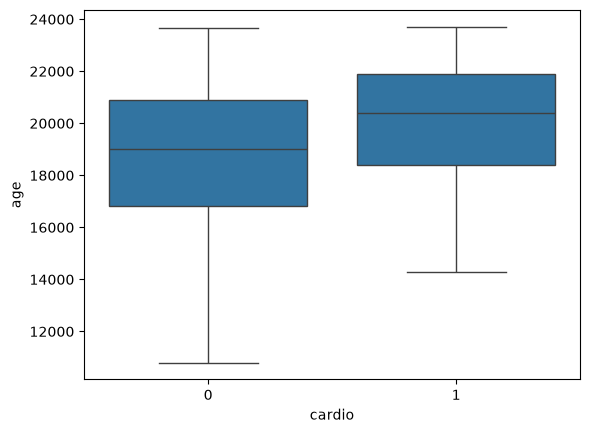

In [18]:
sns.boxplot(x="cardio", y="age", data=df)
plt.show()

## Converting Age from Days to Years

In [19]:
df["age"] = df["age"] / 365

## Age vs Cardio (Boxplot, After Conversion)

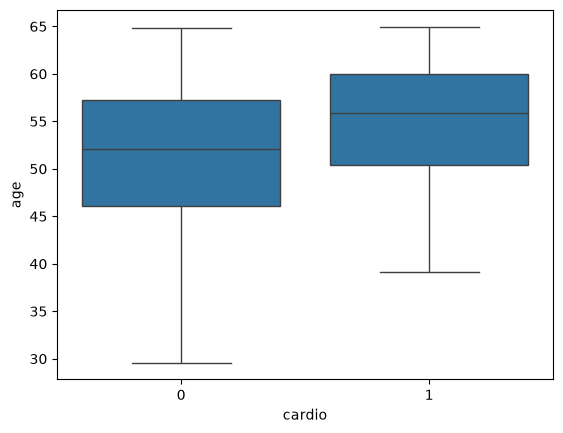

In [20]:
sns.boxplot(x="cardio", y="age", data=df)
plt.show()

## Height vs Cardio (Boxplot)

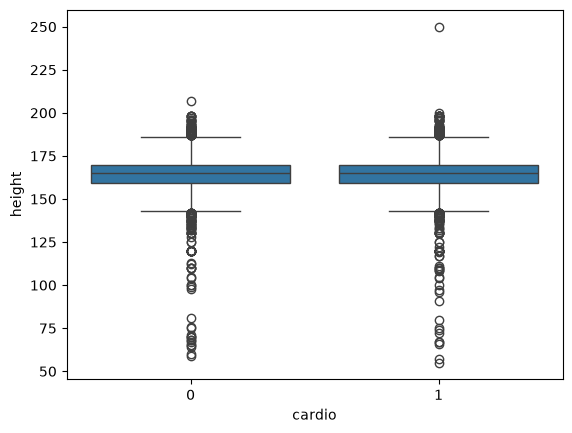

In [21]:
sns.boxplot(x="cardio", y="height", data=df)
plt.show()

## Distribution of Age (Histogram)

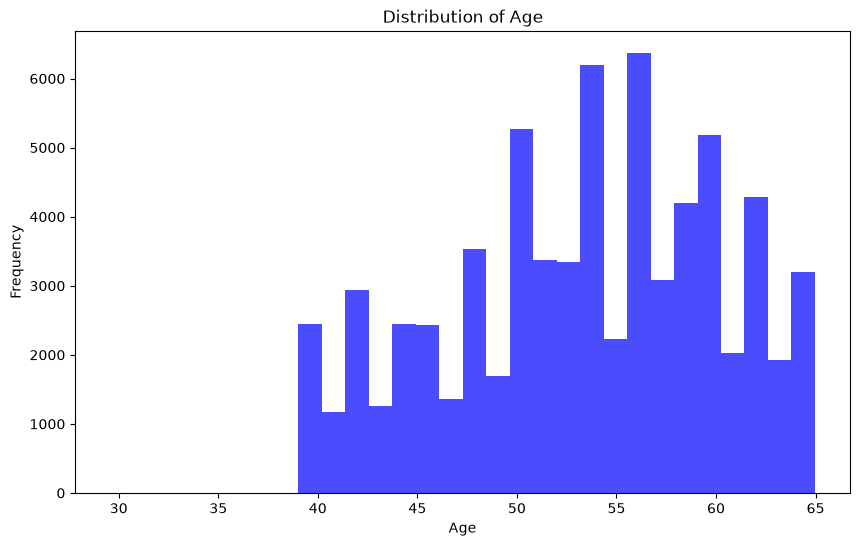

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df["age"], bins=30, color="blue", alpha=0.7)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Distribution of Age (Pandas Histogram)

<Axes: >

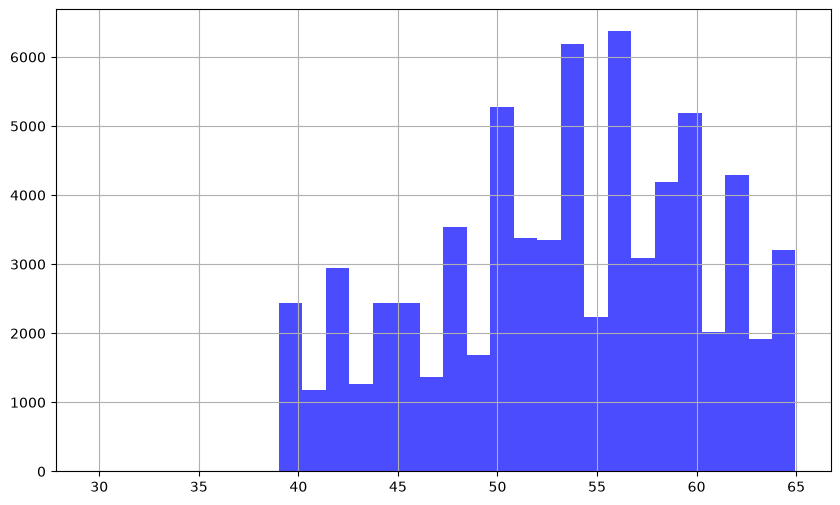

In [23]:
df["age"].hist(bins=30, figsize=(10, 6), color="blue", alpha=0.7)

## Cardio Value Counts (Bar Chart)

<Axes: xlabel='cardio'>

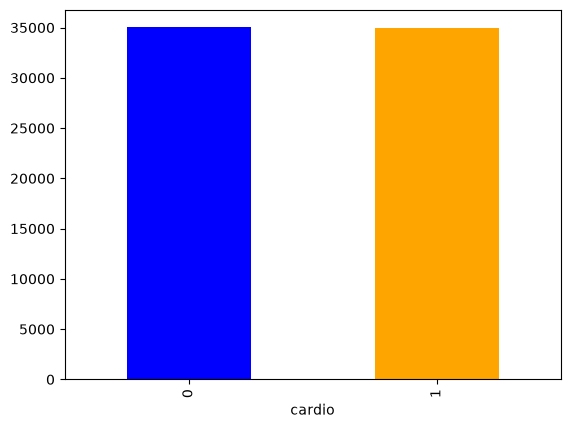

In [24]:
df["cardio"].value_counts().plot(kind="bar", color=["blue", "orange"])

## Sorting Values by Age

In [25]:
df.sort_values(by="age", ascending=False).head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
57191,81643,64.967123,2,175,75.0,120,80,1,1,0,0,1,1
68005,97124,64.934247,1,178,75.0,120,80,1,1,0,0,1,1
50714,72373,64.909589,2,167,68.0,120,80,2,2,0,0,0,1
20931,29892,64.904110,1,165,63.0,150,90,2,1,0,0,1,1
36603,52297,64.895890,2,163,55.0,120,80,3,1,1,0,1,1
37677,53805,64.887671,2,165,64.0,120,80,1,1,0,0,1,1
40099,57321,64.871233,1,165,74.0,120,80,1,1,0,0,1,0
69142,98749,64.868493,1,169,70.0,120,80,3,3,0,0,1,1
57853,82562,64.863014,1,165,65.0,130,80,1,1,0,0,1,1
18062,25799,64.863014,1,140,48.0,170,100,2,1,0,0,1,1


## Linear Regression Model

In [26]:
# linear regression model
model = LinearRegression()

# fitting the model
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-0. , 0. , 0.02,...,-0.02,-0.03,-0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['id','age','gender',...,'smoke','alco','active']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.4933
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Making Predictions

In [27]:
y_pred = model.predict(x_test)

## Evaluating the Model

In [28]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
mse

0.21806032857633317

## Actual vs Predicted Values (Line Plot)

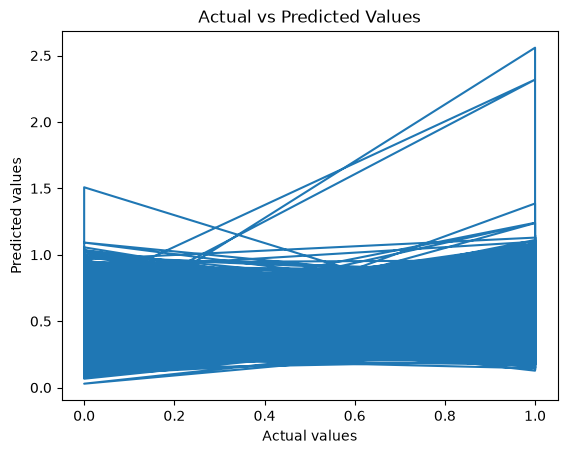

In [29]:
plt.plot(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted Values")
plt.show()

## Actual vs Predicted Values (Scatter Plot)

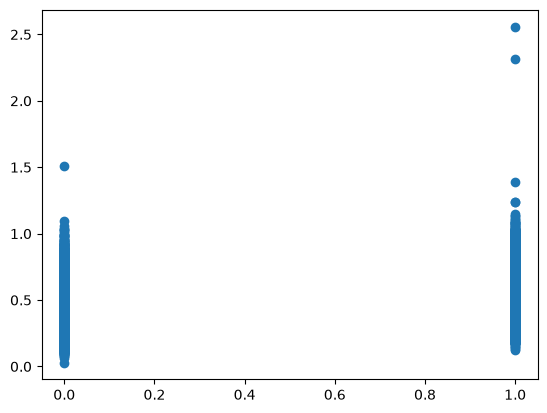

In [30]:
plt.scatter(y_test, y_pred)